# Orquestador de experimentos del proyecto

Este notebook coordina los experimentos centrales de descomposición intrínseca ya definidos en `configs/`. No descarga datos ni implementa métodos nuevos. La lógica del proyecto sigue viviendo en `src/` y la ejecución reproducible se hace mediante `scripts/run_experiment.py`.

## 1. Preparación

La primera celda localiza la raíz del proyecto, agrega `src/` al path y carga librerías de orquestación. Si el notebook se abre desde `notebooks/` o desde la raíz del repositorio, la ruta se resuelve de la misma forma.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

# Preparar la raíz del repositorio.
project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent
elif not (project_root / "configs").exists():
    project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

configs_dir = project_root / "configs"
tables_dir = project_root / "results" / "tables"
runner = project_root / "scripts" / "run_experiment.py"

print(f"Proyecto: {project_root}")
print(f"Runner:   {runner}")

Proyecto: C:\Users\Jorge_UC\OneDrive - Universidad Católica de Chile\2 UC\3\Ramos\PMI\Proyecto
Runner:   C:\Users\Jorge_UC\OneDrive - Universidad Católica de Chile\2 UC\3\Ramos\PMI\Proyecto\scripts\run_experiment.py


## 2. Selección de experimentos

Los grupos siguientes apuntan a los experimentos que sostienen el informe. `mit_principal` resume el benchmark real, `sintel_principal` resume la generalización sintética y `todo` ejecuta todas las configuraciones disponibles. Ambos grupos principales ya incluyen la variante ganadora del método final (`d2_graddom_mit` / `d2_graddom_sintel`, atenuación continua en dominio de gradiente).

Además hay tres grupos de ablación de hiperparámetros:

1. `ablacion_alpha`: sensibilidad del umbral `threshold_factor` (α) en Starlet+color (MIT) y MMT (Sintel), con α ∈ {1.0, 1.5, 2.0, 2.5, 3.0}.
2. `ablacion_beta_color`: sensibilidad de `color_beta` (β) y `color_threshold` (T_color) en las mismas configuraciones destacadas.
3. `ablacion_baselines`: un valor alternativo de sigma/threshold para cada baseline (Homomórfico, SSR, MSR, Horn) en ambos datasets, para revisar qué tan sensible es la comparación a esos parámetros.

Cada grupo incluye también el experimento ya existente (α=2.0, β=0.5, etc.) como punto de referencia, para comparar directamente en la misma tabla.

`ablaciones_hiperparametros` es la unión de los tres (35 experimentos, sin duplicados) para correr **todo en una sola pasada**: pon `experiment_group = "ablaciones_hiperparametros"` y `run_experiments = True`. Si prefieres correrlas por separado, usa los tres grupos individuales uno a la vez.


In [2]:
all_config_ids = sorted(path.stem for path in configs_dir.glob("*.yaml"))

experiment_groups = {
    "mit_principal": [
        "f1_homomorphic",
        "f2_ssr",
        "f2_msr",
        "f2_horn",
        "f3_starlet_color",
        "f3_wavelet_all",
        "f3_mmt",
        "d2_graddom_mit",
    ],
    "sintel_principal": [
        "f2_sintel_homomorphic",
        "f2_sintel_ssr",
        "f2_sintel_msr",
        "f2_sintel_horn",
        "f2_sintel_starlet",
        "f3_sintel_wavelet_all",
        "f3_sintel_mmt",
        "d2_graddom_sintel",
    ],
    "ablacion_alpha": [
        "f3_starlet_color_a1.0",
        "f3_starlet_color_a1.5",
        "f3_starlet_color",
        "f3_starlet_color_a2.5",
        "f3_starlet_color_a3.0",
        "f3_sintel_mmt_a1.0",
        "f3_sintel_mmt_a1.5",
        "f3_sintel_mmt",
        "f3_sintel_mmt_a2.5",
        "f3_sintel_mmt_a3.0",
    ],
    "ablacion_beta_color": [
        "f3_starlet_color_b0.25",
        "f3_starlet_color",
        "f3_starlet_color_b0.75",
        "f3_starlet_color_tc0.02",
        "f3_starlet_color_tc0.1",
        "f3_sintel_mmt_all_b0.25",
        "f3_sintel_mmt_all",
        "f3_sintel_mmt_all_b0.75",
        "f3_sintel_mmt_all_tc0.02",
        "f3_sintel_mmt_all_tc0.1",
    ],
    "ablacion_baselines": [
        "f1_homomorphic",
        "f1_homomorphic_s30",
        "f2_sintel_homomorphic",
        "f2_sintel_homomorphic_s30",
        "f2_ssr",
        "f2_ssr_s30",
        "f2_sintel_ssr",
        "f2_sintel_ssr_s30",
        "f2_msr",
        "f2_msr_wide",
        "f2_sintel_msr",
        "f2_sintel_msr_wide",
        "f2_horn",
        "f2_horn_t0.2",
        "f2_sintel_horn",
        "f2_sintel_horn_t0.2",
    ],
    "todo": all_config_ids,
}

# Union de las tres ablaciones de hiperparametros, sin duplicados, para
# correrlas todas en una sola pasada del notebook.
experiment_groups["ablaciones_hiperparametros"] = list(dict.fromkeys(
    experiment_groups["ablacion_alpha"]
    + experiment_groups["ablacion_beta_color"]
    + experiment_groups["ablacion_baselines"]
))

# Cambia este valor si quieres orquestar otro bloque.
# Para correr las tres ablaciones de hiperparametros de una sola vez:
#   experiment_group = "ablaciones_hiperparametros"
# Para correrlas por separado, usa una a la vez:
#   "ablacion_alpha" -> "ablacion_beta_color" -> "ablacion_baselines"
experiment_group = "mit_principal"

# Deja False para leer CSV existentes. Cambia a True para recalcular.
run_experiments = False

selected_ids = experiment_groups[experiment_group]
selected_configs = [configs_dir / f"{exp_id}.yaml" for exp_id in selected_ids]
missing_configs = [path for path in selected_configs if not path.exists()]

if missing_configs:
    raise FileNotFoundError(missing_configs)

print(f"Grupo seleccionado: {experiment_group}")
print(f"Experimentos: {len(selected_ids)}")
display(pd.DataFrame({"experiment_id": selected_ids}))

Grupo seleccionado: mit_principal
Experimentos: 8


,experiment_id
0,f1_homomorphic
1,f2_ssr
2,f2_msr
3,f2_horn
4,f3_starlet_color
5,f3_wavelet_all
6,f3_mmt
7,d2_graddom_mit


## 3. Lectura de configuraciones

Esta tabla muestra qué dataset, método, transformada y regla se ejecutará. La información se lee directamente desde los YAML para evitar duplicar parámetros en el notebook.

In [3]:
config_rows = []

for exp_id in selected_ids:
    config_path = configs_dir / f"{exp_id}.yaml"

    with open(config_path, "r", encoding="utf-8") as file:
        config = yaml.safe_load(file)

    params = config.get("params", {})
    rule_parts = []

    if params.get("scale_coherence"):
        rule_parts.append("escala")

    if params.get("color_coherence"):
        rule_parts.append("color")

    if not rule_parts and config.get("method") in ["starlet", "mmt", "multiscale"]:
        rule_parts.append("magnitud")

    if config.get("method") == "gradient_domain":
        rule_parts.append("gradiente-continuo")
        if params.get("chroma_modulation"):
            rule_parts.append("croma")

    config_rows.append({
        "experiment_id": exp_id,
        "dataset": config.get("dataset"),
        "method": config.get("method"),
        "transform": params.get("transform_type", config.get("method")),
        "levels": params.get("levels", ""),
        "rule": " + ".join(rule_parts) if rule_parts else "baseline",
        "config": str(config_path.relative_to(project_root)),
    })

config_table = pd.DataFrame(config_rows)
display(config_table)

,experiment_id,dataset,method,transform,levels,rule,config
0,f1_homomorphic,mit,homomorphic,homomorphic,,baseline,configs\f1_homomorphic.yaml
1,f2_ssr,mit,ssr,ssr,,baseline,configs\f2_ssr.yaml
2,f2_msr,mit,msr,msr,,baseline,configs\f2_msr.yaml
3,f2_horn,mit,horn,horn,,baseline,configs\f2_horn.yaml
4,f3_starlet_color,mit,starlet,starlet,3,color,configs\f3_starlet_color.yaml
5,f3_wavelet_all,mit,multiscale,wavelet,3,escala + color,configs\f3_wavelet_all.yaml
6,f3_mmt,mit,mmt,mmt,3,magnitud,configs\f3_mmt.yaml
7,d2_graddom_mit,mit,gradient_domain,gradient_domain,3,gradiente-continuo,configs\d2_graddom_mit.yaml


## 4. Ejecución orquestada

La ejecución usa el mismo comando reproducible definido para el proyecto: `python scripts/run_experiment.py --config configs/<id>.yaml`. Si `run_experiments` está en `False`, el notebook solo lee resultados ya generados desde `results/tables/`.

In [4]:
if run_experiments:
    for config_path in selected_configs:
        print(f"Ejecutando {config_path.relative_to(project_root)}")
        subprocess.run(
            [sys.executable, str(runner), "--config", str(config_path)],
            cwd=project_root,
            check=True,
        )
else:
    print("Ejecución desactivada. Se leerán los CSV existentes.")

Ejecución desactivada. Se leerán los CSV existentes.


## 5. Resumen cuantitativo

Cada CSV contiene resultados por objeto o frame y una fila `Average`. La tabla siguiente toma esa fila promedio para comparar directamente los métodos del grupo seleccionado.

In [5]:
def load_average_row(exp_id):
    csv_path = tables_dir / f"{exp_id}.csv"

    if not csv_path.exists():
        raise FileNotFoundError(csv_path)

    table = pd.read_csv(csv_path)
    average = table.loc[table["Object"].astype(str) == "Average"].iloc[0].copy()
    average["experiment_id"] = exp_id
    return average


summary_rows = [load_average_row(exp_id) for exp_id in selected_ids]
summary = pd.DataFrame(summary_rows)

summary = summary.merge(config_table, on="experiment_id", how="left")

summary_columns = [
    "experiment_id",
    "dataset",
    "method",
    "transform",
    "rule",
    "Combined_LMSE",
    "Refl_LMSE",
    "Shading_LMSE",
    "Refl_siMSE",
    "Refl_PSNR",
    "Refl_SSIM",
    "Refl_DSSIM",
    "Refl_Sparsity",
    "Time_s",
]

summary = summary[summary_columns]
display(summary.round(4))

,experiment_id,dataset,method,transform,rule,Combined_LMSE,Refl_LMSE,Shading_LMSE,Refl_siMSE,Refl_PSNR,Refl_SSIM,Refl_DSSIM,Refl_Sparsity,Time_s
0,f1_homomorphic,mit,homomorphic,homomorphic,baseline,0.0569,0.0742,0.0395,0.0530,13.6812,0.8168,0.0916,0.1406,0.0146
1,f2_ssr,mit,ssr,ssr,baseline,0.0568,0.0746,0.0390,0.0533,13.7612,0.8130,0.0935,0.2024,0.0120
2,f2_msr,mit,msr,msr,baseline,0.0579,0.0767,0.0391,0.0661,13.6267,0.8196,0.0902,0.2442,0.2027
3,f2_horn,mit,horn,horn,baseline,0.0487,0.0496,0.0479,0.0460,14.6011,0.8310,0.0845,0.6998,0.5272
4,f3_starlet_color,mit,starlet,starlet,color,0.0596,0.0674,0.0518,0.0444,14.3421,0.8052,0.0974,0.1842,0.0351
5,f3_wavelet_all,mit,multiscale,wavelet,escala + color,0.0666,0.0695,0.0637,0.0451,14.4404,0.8059,0.0971,0.1987,0.0721
6,f3_mmt,mit,mmt,mmt,magnitud,0.0681,0.0717,0.0645,0.0507,14.3996,0.8073,0.0963,0.2320,0.0624
7,d2_graddom_mit,mit,gradient_domain,gradient_domain,gradiente-continuo,0.0501,0.0612,0.0389,0.0610,13.4060,0.8077,0.0961,0.6441,1.3826


## 6. Lectura automática del mejor LMSE

Esta celda no reemplaza el análisis del informe. Solo identifica el mejor promedio del bloque seleccionado para orientar la revisión.

In [6]:
best_index = summary["Combined_LMSE"].idxmin()
best_row = summary.loc[best_index]

print("Mejor promedio del grupo seleccionado")
print(f"Experimento: {best_row['experiment_id']}")
print(f"Método:      {best_row['method']}")
print(f"LMSE:        {best_row['Combined_LMSE']:.4f}")
print(f"Tiempo:      {best_row['Time_s']:.4f} s")

Mejor promedio del grupo seleccionado
Experimento: f2_horn
Método:      horn
LMSE:        0.0487
Tiempo:      0.5272 s


## 7. Gráfico comparativo

El gráfico ordena los experimentos por LMSE combinado. Valores menores indican una mejor reconstrucción promedio bajo la métrica principal del proyecto.

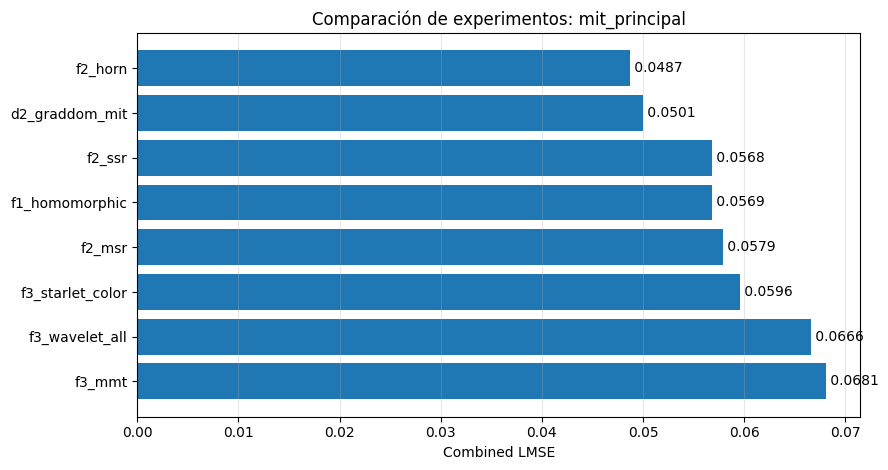

In [7]:
plot_table = summary.sort_values("Combined_LMSE", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(plot_table["experiment_id"], plot_table["Combined_LMSE"])
ax.invert_yaxis()
ax.set_xlabel("Combined LMSE")
ax.set_title(f"Comparación de experimentos: {experiment_group}")
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_table["Combined_LMSE"]):
    ax.text(value, index, f" {value:.4f}", va="center")

plt.tight_layout()
plt.show()

## 8. Comparación precisión y costo

Esta vista cruza el LMSE con el tiempo promedio por imagen. Ayuda a defender por qué un método puede ser atractivo aunque no sea el menor error absoluto.

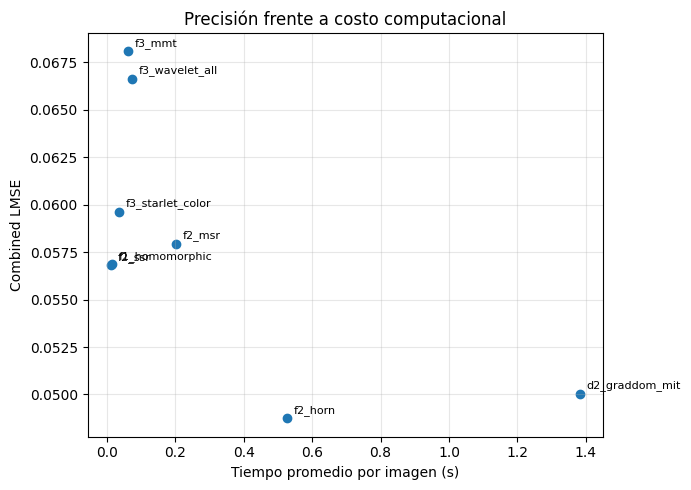

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(summary["Time_s"], summary["Combined_LMSE"])

for _, row in summary.iterrows():
    ax.annotate(
        row["experiment_id"],
        (row["Time_s"], row["Combined_LMSE"]),
        textcoords="offset points",
        xytext=(5, 4),
        fontsize=8,
    )

ax.set_xlabel("Tiempo promedio por imagen (s)")
ax.set_ylabel("Combined LMSE")
ax.set_title("Precisión frente a costo computacional")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Visualización comparativa multiescala

Esta sección complementa las tablas del informe con ejemplos visuales. Se comparan Starlet, Wavelet SWT db2 y MMT sobre los mismos ejemplos, usando la reflectancia ground-truth y mapas de error absoluto alineados a escala. El shading estimado no se muestra en la grilla para mantener la comparación legible.


In [9]:
import numpy as np

from src.baselines.homomorphic import homomorphic_decomposition
from src.baselines.ssr import ssr_decomposition
from src.baselines.msr import msr_decomposition
from src.baselines.horn import horn_decomposition
from src.data.mit import MITIntrinsicDataset
from src.data.sintel import MPISintelDataset
from src.decompose.multiscale import multiscale_decomposition
from src.decompose.gradient_domain import gradient_domain_decomposition
from src.metrics.extra import masked_psnr, masked_ssim, scale_to_reference
from src.metrics.lmse import local_error


def load_config(exp_id):
    config_path = configs_dir / f"{exp_id}.yaml"

    with open(config_path, "r", encoding="utf-8") as file:
        return yaml.safe_load(file)


def run_decomposition_from_config(diffuse, mask, exp_id):
    config = load_config(exp_id)
    method = config.get("method")
    params = dict(config.get("params", {}))

    if method == "homomorphic":
        return homomorphic_decomposition(diffuse, mask, **params)

    if method == "ssr":
        return ssr_decomposition(diffuse, mask, **params)

    if method == "msr":
        return msr_decomposition(diffuse, mask, **params)

    if method == "horn":
        return horn_decomposition(diffuse, mask, **params)

    if method in ["starlet", "mmt", "multiscale"]:
        return multiscale_decomposition(diffuse, mask, **params)

    if method == "gradient_domain":
        return gradient_domain_decomposition(diffuse, mask, **params)

    raise ValueError(f"Metodo no soportado: {method}")


def to_gray(image):
    if image.ndim == 3:
        return np.mean(image, axis=2)

    return image


def compute_example_metrics(data, est_shading, est_refl):
    mask = data["mask"]
    true_refl_gray = to_gray(data["reflectance"])
    true_shading_gray = to_gray(data["shading"])
    est_refl_gray = to_gray(est_refl)
    est_shading_gray = to_gray(est_shading)

    refl_lmse = local_error(true_refl_gray, est_refl_gray, mask, window_size=20, window_shift=10)
    shading_lmse = local_error(true_shading_gray, est_shading_gray, mask, window_size=20, window_shift=10)
    combined_lmse = 0.5 * refl_lmse + 0.5 * shading_lmse
    refl_psnr = masked_psnr(true_refl_gray, est_refl_gray, mask)
    refl_ssim = masked_ssim(true_refl_gray, est_refl_gray, mask)

    aligned_refl = scale_to_reference(true_refl_gray, est_refl_gray, mask)
    error_map = np.where(mask, np.abs(true_refl_gray - aligned_refl), np.nan)

    metrics = {
        "Refl_LMSE": refl_lmse,
        "Shading_LMSE": shading_lmse,
        "Combined_LMSE": combined_lmse,
        "Refl_PSNR": refl_psnr,
        "Refl_SSIM": refl_ssim,
    }

    return metrics, error_map


def show_rgb(ax, image, title):
    ax.imshow(np.clip(image, 0.0, 1.0))
    ax.set_title(title, fontsize=8)
    ax.axis("off")


def show_multiscale_comparison(dataset_name, items, experiments, output_path):
    rows = 2 * len(items)
    cols = 2 + len(experiments)
    fig_height = 3.1 * len(items)
    fig_width = 4.5 + 3.0 * len(experiments)
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
    grid = fig.add_gridspec(
        rows,
        cols,
        width_ratios=[0.9, 0.9] + [1.15] * len(experiments),
    )

    error_cmap = plt.get_cmap("magma").copy()
    error_cmap.set_bad(color="black")
    error_axes = []
    last_error = None
    records = []

    for item_index, item in enumerate(items):
        image_row = 2 * item_index
        error_row = image_row + 1

        if dataset_name == "mit":
            example_id, data = item
            item_title = example_id
            summary_id = example_id
        else:
            scene_id, frame_file, data = item
            frame_label = frame_file.replace(".png", "")
            item_title = f"{scene_id}\n{frame_label}"
            summary_id = f"{scene_id}/{frame_label}"

        input_ax = fig.add_subplot(grid[image_row:error_row + 1, 0])
        gt_ax = fig.add_subplot(grid[image_row:error_row + 1, 1])
        show_rgb(input_ax, data["diffuse"], f"Entrada\n{item_title}")
        show_rgb(gt_ax, data["reflectance"], "Reflectancia\nGT")

        for method_index, method_info in enumerate(experiments):
            method_label, exp_id = method_info
            est_shading, est_refl = run_decomposition_from_config(
                data["diffuse"],
                data["mask"],
                exp_id,
            )
            metrics, error_map = compute_example_metrics(data, est_shading, est_refl)
            col = 2 + method_index

            estimate_ax = fig.add_subplot(grid[image_row, col])
            error_ax = fig.add_subplot(grid[error_row, col])
            show_rgb(estimate_ax, est_refl, f"{method_label}\nR estimada")
            last_error = error_ax.imshow(
                error_map,
                cmap=error_cmap,
                vmin=0.0,
                vmax=0.5,
            )
            error_ax.set_title(
                f"Error {method_label}\nLMSE {metrics['Refl_LMSE']:.3f}",
                fontsize=8,
            )
            error_ax.axis("off")
            error_axes.append(error_ax)

            records.append({
                "dataset": dataset_name,
                "example": summary_id,
                "experiment_id": exp_id,
                **metrics,
            })

    colorbar = fig.colorbar(
        last_error,
        ax=error_axes,
        fraction=0.02,
        pad=0.015,
    )
    colorbar.set_label("Error abs.", fontsize=8)
    colorbar.ax.tick_params(labelsize=8)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(records)

## 10. Comparación visual MIT

Se usan tres objetos del benchmark MIT (`box`, `cup1` y `paper1`). La grilla mantiene fija la entrada y el ground-truth de reflectancia, y compara las tres transformadas multiescala principales más el método final (atenuación continua en dominio de gradiente) bajo la misma escala de error.


C:\Users\Jorge_UC\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyamg\classical\classical.py:100: SparseEfficiencyWarning: Implicit conversion of A to CSR
  warn('Implicit conversion of A to CSR', SparseEfficiencyWarning)


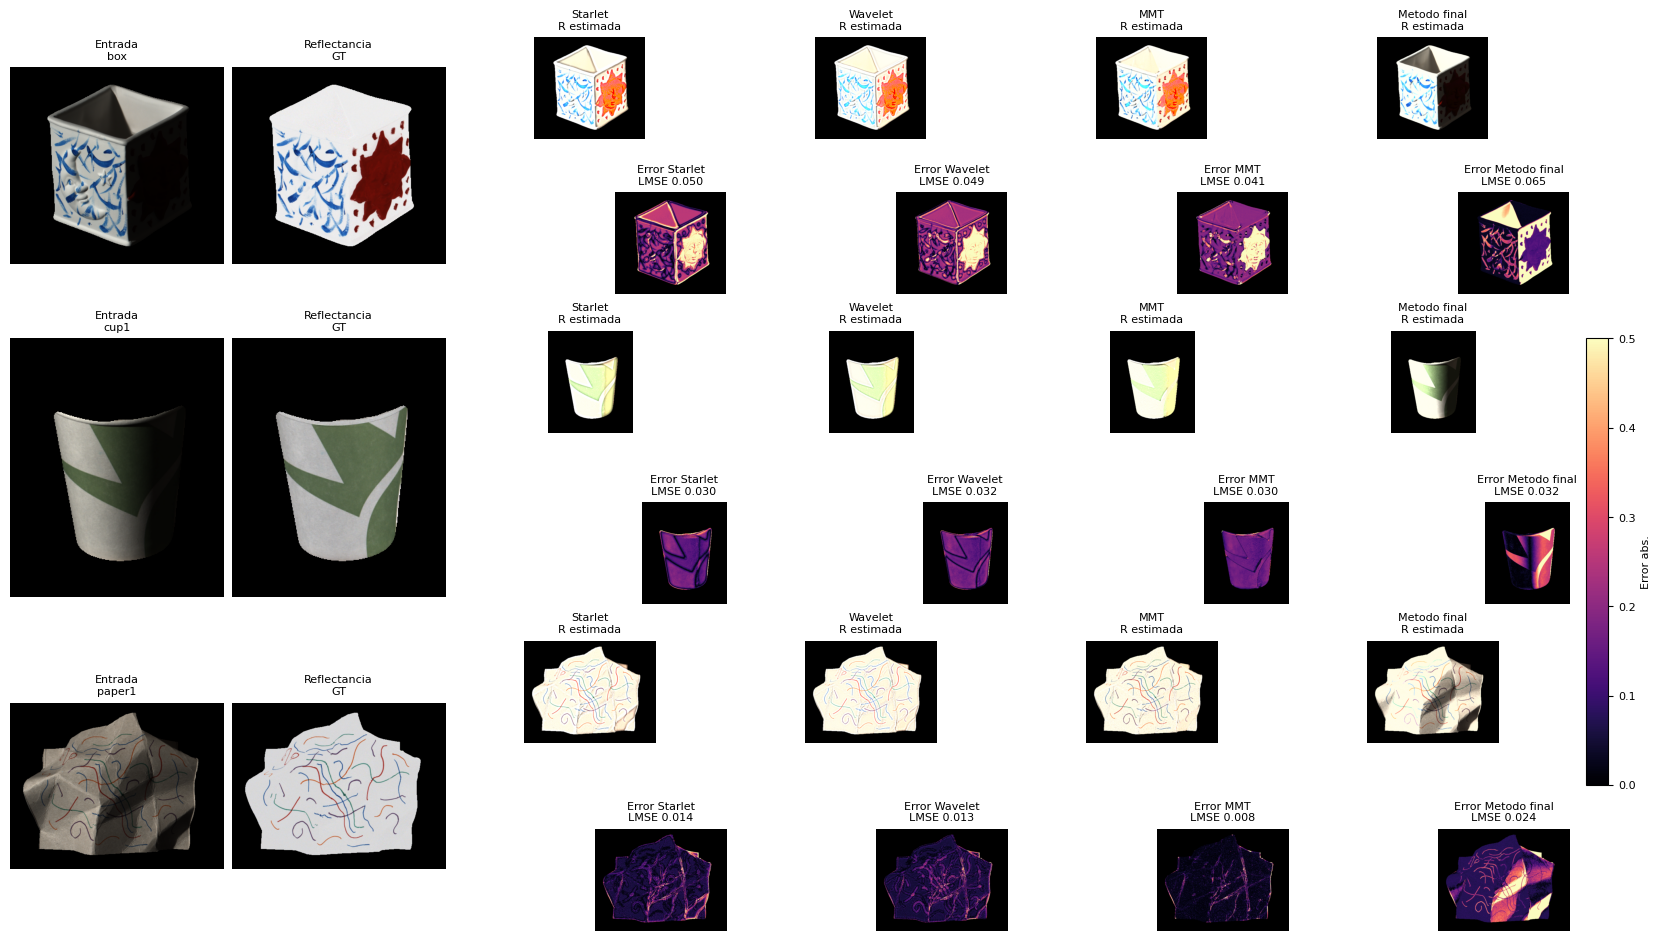

,dataset,example,experiment_id,Refl_LMSE,Shading_LMSE,Combined_LMSE,Refl_PSNR,Refl_SSIM
0,mit,box,f3_starlet_color,0.0501,0.0262,0.0381,10.4765,0.7643
1,mit,box,f3_wavelet_all,0.0485,0.0365,0.0425,10.3595,0.7555
2,mit,box,f3_mmt,0.0414,0.0291,0.0353,10.1964,0.8073
3,mit,box,d2_graddom_mit,0.0646,0.0325,0.0485,8.2044,0.7523
4,mit,cup1,f3_starlet_color,0.0299,0.0197,0.0248,15.9806,0.9086
5,mit,cup1,f3_wavelet_all,0.0321,0.0220,0.0270,15.7401,0.9095
6,mit,cup1,f3_mmt,0.0296,0.0207,0.0252,15.5479,0.9221
7,mit,cup1,d2_graddom_mit,0.0319,0.0080,0.0199,12.0845,0.8690
8,mit,paper1,f3_starlet_color,0.0145,0.0077,0.0111,18.8460,0.7673
9,mit,paper1,f3_wavelet_all,0.0131,0.0088,0.0110,19.4582,0.7722


In [10]:
mit_visual_items = [
    "box",
    "cup1",
    "paper1",
]
mit_visual_experiments = [
    ("Starlet", "f3_starlet_color"),
    ("Wavelet", "f3_wavelet_all"),
    ("MMT", "f3_mmt"),
    ("Metodo final", "d2_graddom_mit"),
]

mit_dataset = MITIntrinsicDataset()
mit_items = [(object_id, mit_dataset.load_object(object_id)) for object_id in mit_visual_items]
mit_visual_summary = show_multiscale_comparison(
    "mit",
    mit_items,
    mit_visual_experiments,
    project_root / "Informe" / "mit_multiscale_comparison.png",
)

display(mit_visual_summary.round(4))

## 11. Comparación visual Sintel

Se usan tres frames de MPI-Sintel (`alley_1`, `ambush_2` y `bamboo_1`, todos `frame_0001`) para complementar MIT con escenas sintéticas densas. La comparación conserva la misma estructura visual y la misma escala de error, e incluye el método final junto a las tres transformadas multiescala principales.

C:\Users\Jorge_UC\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyamg\classical\classical.py:100: SparseEfficiencyWarning: Implicit conversion of A to CSR
  warn('Implicit conversion of A to CSR', SparseEfficiencyWarning)


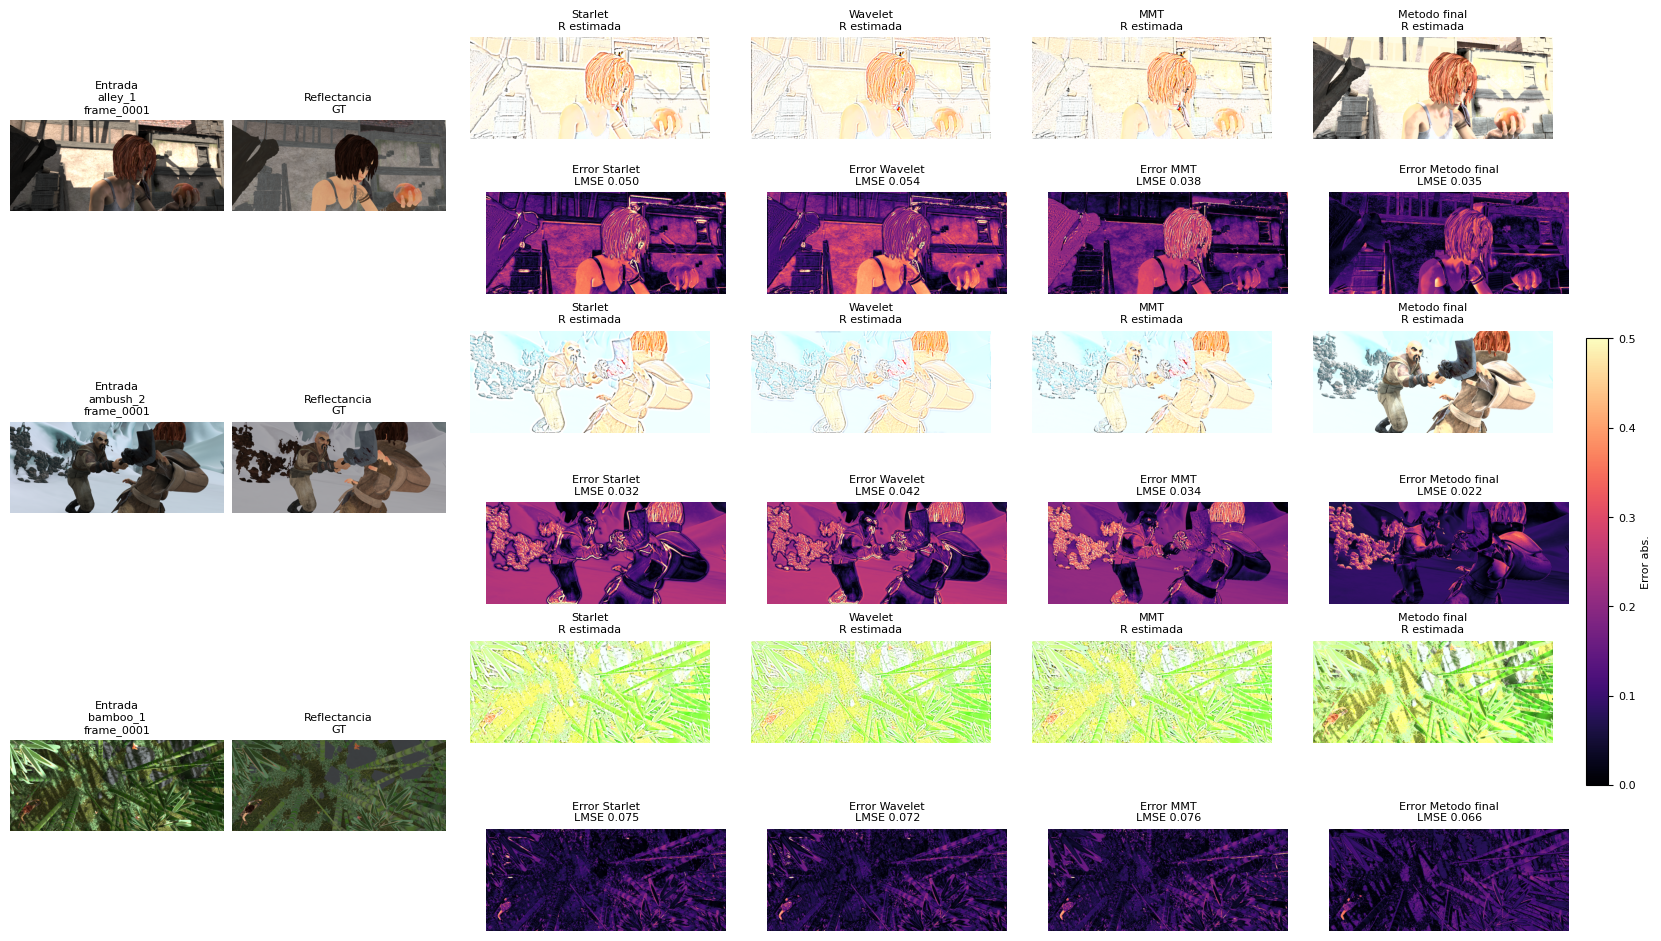

,dataset,example,experiment_id,Refl_LMSE,Shading_LMSE,Combined_LMSE,Refl_PSNR,Refl_SSIM
0,sintel,alley_1/frame_0001,f2_sintel_starlet,0.0500,0.0398,0.0449,13.3405,0.4871
1,sintel,alley_1/frame_0001,f3_sintel_wavelet_all,0.0543,0.0484,0.0514,12.0554,0.4931
2,sintel,alley_1/frame_0001,f3_sintel_mmt,0.0379,0.0386,0.0383,15.1985,0.5708
3,sintel,alley_1/frame_0001,d2_graddom_sintel,0.0350,0.0243,0.0297,17.4715,0.5707
4,sintel,ambush_2/frame_0001,f2_sintel_starlet,0.0319,0.0285,0.0302,12.8214,0.6550
5,sintel,ambush_2/frame_0001,f3_sintel_wavelet_all,0.0424,0.0396,0.0410,12.2878,0.6439
6,sintel,ambush_2/frame_0001,f3_sintel_mmt,0.0338,0.0365,0.0352,13.5424,0.6836
7,sintel,ambush_2/frame_0001,d2_graddom_sintel,0.0220,0.0118,0.0169,17.8281,0.7591
8,sintel,bamboo_1/frame_0001,f2_sintel_starlet,0.0745,0.0457,0.0601,21.1971,0.6125
9,sintel,bamboo_1/frame_0001,f3_sintel_wavelet_all,0.0719,0.0506,0.0612,21.1469,0.6292


In [11]:
sintel_visual_items = [
    ("alley_1", "frame_0001.png"),
    ("ambush_2", "frame_0001.png"),
    ("bamboo_1", "frame_0001.png"),
]
sintel_visual_experiments = [
    ("Starlet", "f2_sintel_starlet"),
    ("Wavelet", "f3_sintel_wavelet_all"),
    ("MMT", "f3_sintel_mmt"),
    ("Metodo final", "d2_graddom_sintel"),
]

sintel_dataset = MPISintelDataset()
sintel_items = [
    (scene_id, frame_file, sintel_dataset.load_frame(scene_id, frame_file))
    for scene_id, frame_file in sintel_visual_items
]
sintel_visual_summary = show_multiscale_comparison(
    "sintel",
    sintel_items,
    sintel_visual_experiments,
    project_root / "Informe" / "sintel_multiscale_comparison.png",
)

display(sintel_visual_summary.round(4))

## 12. Piramide de residuos: demostracion sobre una imagen real

El metodo final no umbraliza coeficientes de detalle: construye su peso continuo
a partir de una piramide de aproximaciones R_0,...,R_L cada vez mas suaves
(Seccion II-C del informe). Esta seccion la calcula y la muestra para un objeto
real de MIT, con la transformada Starlet (la variante de referencia), para que
se vea sobre una imagen concreta lo que hasta aqui era solo una formula.

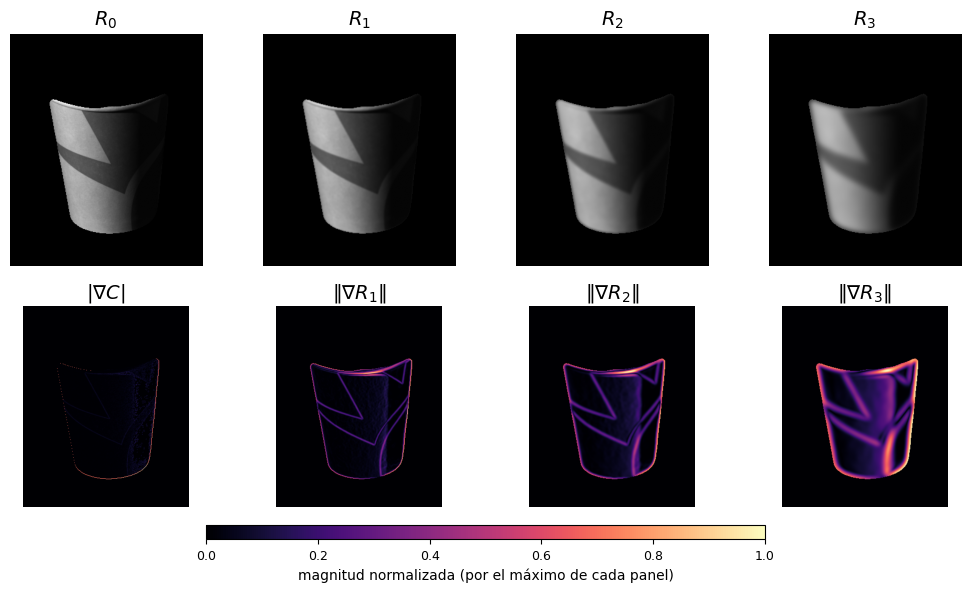

In [12]:
from src.baselines.homomorphic import rgb_to_luminance
from src.decompose.gradient_domain import residual_pyramid, centered_gradient_magnitude

pyramid_object_id = "cup1"
pyramid_levels = 3
pyramid_data = dict(mit_items)[pyramid_object_id]
pyramid_diffuse = pyramid_data["diffuse"]
pyramid_mask = pyramid_data["mask"]

pyramid_L = rgb_to_luminance(pyramid_diffuse)
pyramid_log_L = np.log(np.clip(pyramid_L, 1e-5, 1.0))
pyramid_fg_mean = np.mean(pyramid_log_L[pyramid_mask])
pyramid_log_L_filled = np.where(pyramid_mask, pyramid_log_L, pyramid_fg_mean)

pyramid = residual_pyramid(pyramid_log_L_filled, pyramid_levels, transform_type="starlet")


def normalize_for_display(field, mask):
    valid = field[mask]
    if valid.size == 0 or valid.max() <= 0:
        return field
    return np.clip(field / valid.max(), 0.0, 1.0)


# Mismo calculo que gradient_domain_decomposition cuando chroma_modulation=True.
pyramid_C = pyramid_diffuse / (pyramid_L[..., np.newaxis] + 1e-5)
grad_C_x = np.zeros_like(pyramid_C)
grad_C_y = np.zeros_like(pyramid_C)
grad_C_x[:, :-1, :] = pyramid_C[:, 1:, :] - pyramid_C[:, :-1, :]
grad_C_y[:-1, :, :] = pyramid_C[1:, :, :] - pyramid_C[:-1, :, :]
grad_C = np.sqrt(np.sum(grad_C_x ** 2 + grad_C_y ** 2, axis=-1)) * pyramid_mask

fig, axes = plt.subplots(2, len(pyramid), figsize=(2.6 * len(pyramid), 5.6))

for k, (ax, R_k) in enumerate(zip(axes[0], pyramid)):
    display_k = np.clip(np.exp(R_k), 0.0, 1.0) * pyramid_mask
    ax.imshow(display_k, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(f"$R_{{{k}}}$", fontsize=14)
    ax.axis("off")

im = axes[1][0].imshow(normalize_for_display(grad_C, pyramid_mask), cmap="magma", vmin=0.0, vmax=1.0)
axes[1][0].set_title(r"$|\nabla C|$", fontsize=14)
axes[1][0].axis("off")

for k in range(1, len(pyramid)):
    grad_mag = centered_gradient_magnitude(pyramid[k])
    grad_mag = normalize_for_display(grad_mag * pyramid_mask, pyramid_mask)
    axes[1][k].imshow(grad_mag, cmap="magma", vmin=0.0, vmax=1.0)
    axes[1][k].set_title(rf"$\|\nabla R_{{{k}}}\|$", fontsize=14)
    axes[1][k].axis("off")

fig.tight_layout()

pyramid_colorbar = fig.colorbar(im, ax=list(axes[1]), orientation="horizontal",
                                 fraction=0.06, pad=0.08, aspect=40)
pyramid_colorbar.set_label("magnitud normalizada (por el máximo de cada panel)", fontsize=10)
pyramid_colorbar.ax.tick_params(labelsize=9)

fig.savefig(project_root / "Informe" / "pyramid_demo.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Qué queda trazado

El notebook deja visible el flujo completo del experimento: selección de YAML, ejecución opcional con el runner oficial, lectura de CSV, comparación de métricas y revisión visual de reflectancia y shading en MIT y Sintel. Por diseño, no descarga datos y no replica la lógica de descomposición que ya está en `src/`.
